In [1]:
from icecube import dataclasses, dataio, icetray, simclasses
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import time
import scipy.constants as spc
from icecube.phys_services import I3Calculator
from matplotlib.colors import LogNorm
from scipy.stats import skew 

In [5]:
def reco_santa(filelist):
    '''
    This function is to get the reco properties
    vertex recostruction(santa)
    zenith(santa)
    azimuth(santa)
    '''

    data = []

    for file in filelistCC:
        #print(file)
        infile=dataio.I3File(file)
        while(infile.more()):
            frame = infile.pop_frame()
            if frame.Stop == icetray.I3Frame.Physics:
                if 'SANTA_Cascade_MS' in frame and 'Strict_Vertex' in frame:
                    mctree = frame["I3MCTree"]
                    primary = mctree.primaries
        
                    daughter = dataclasses.I3MCTree.first_child(mctree, primary[0].id)
                    rc_x, rc_y, rc_z = frame['SANTA_Cascade_MS'].pos
                    rt_x, rt_y, rt_z = frame['SANTA_Track_MS'].pos
                    px, py, pz = primary[0].pos
        
                    data.append((rc_x, rc_y, rc_z, rt_x, rt_y, rt_z, px, py, pz))
                
    return map(np.array, zip(*data)) if data else (np.array([]),) * 9

In [6]:
filelistCC = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/CC_santa/upgrade_genie_level4_queso_*.i3.zst'))
filelistNC = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/NC_santa/upgrade_genie_level4_queso_*.i3.zst'))

In [7]:
rc_xCC, rc_yCC, rc_zCC, rt_xCC, rt_yCC, rt_zCC, pxCC, pyCC, pzCC = reco_santa(filelistCC)

In [8]:
def make_plot(trueR, recoR, trueZ, recoZ, label):

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(trueR, recoR, bins=(100, 100), norm=LogNorm(), cmap='jet')
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel('true R', fontsize = 18)
    axs[0].set_ylabel('reco R', fontsize = 18)
    
    lims = [
        np.min([axs[0].get_xlim(), axs[0].get_ylim()]),
        np.max([axs[0].get_xlim(), axs[0].get_ylim()]),
    ]
    
    axs[0].plot(lims, lims, 'k-', lw=3)
    
    a1 = axs[1].hist2d(trueZ, recoZ, bins=(100, 100), norm=LogNorm(), cmap='jet')
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel('true Z', fontsize = 18)
    axs[1].set_ylabel('reco Z', fontsize = 18)
    
    lims = [
        np.min([axs[1].get_xlim(), axs[1].get_ylim()]),
        np.max([axs[1].get_xlim(), axs[1].get_ylim()]),
    ]
    
    axs[1].plot(lims, lims, 'k-', lw=3)
    
    fig.suptitle(label, fontsize=18)
    plt.show()

def get_statistics(position, trueR, recoR):
    ed = np.sqrt((position[0]-position[3])**2
                 +(position[1]-position[4])**2
                 +(position[2]-position[5])**2)

    cosine_sim = ((position[0]*position[3])
                  +(position[1]*position[4])
                  +(position[2]*position[5]))/(trueR*recoR)

    mae_x = np.mean(abs(position[0]-position[3]))
    mae_y = np.mean(abs(position[1]-position[4]))
    mae_z = np.mean(abs(position[2]-position[5]))

    print(skew(ed, axis=0, bias=True))
    
    plt.hist(ed, bins=80, histtype='step', log=True, lw=2)
    plt.axvline(np.mean(ed), c='r', lw=2, label = f"Mean: {np.round(np.mean(ed), 2)} | Std: {np.round(np.std(ed), 2)}")
    plt.legend()
    plt.xlabel('Euclidean Distance')
    plt.show()
    
    plt.hist(cosine_sim, bins=80, histtype='step', log=True, lw=2)
    plt.axvline(np.mean(cosine_sim), c='r', lw=2, label = f"Mean: {np.round(np.mean(cosine_sim), 2)} | Std: {np.round(np.std(cosine_sim), 2)}")
    plt.legend()
    plt.xlabel('Cosine Similarity')
    plt.show()

    plt.hist(position[0]-position[3], bins=80, histtype='step', log=True, lw=2, label='MAE x: '+str(np.round(mae_x, 1)))
    plt.hist(position[1]-position[4], bins=80, histtype='step', log=True, lw=2, label='MAE y: '+str(np.round(mae_y, 1)))
    plt.hist(position[2]-position[5], bins=80, histtype='step', log=True, lw=2, label='MAE z: '+str(np.round(mae_z, 1)))
    plt.xlabel('true pos - pred pos')
    plt.legend()
    plt.show()
    
def understand_model(position, label):
    
    trueR = np.sqrt(position[0]**2+position[1]**2+position[2]**2)
    recoR = np.sqrt(position[3]**2+position[4]**2+position[5]**2)

    make_plot(trueR, recoR, position[2], position[5], label)
    get_statistics(position, trueR, recoR)

In [9]:
position = [pxCC, pyCC, pzCC, rc_xCC, rc_yCC, rc_zCC]

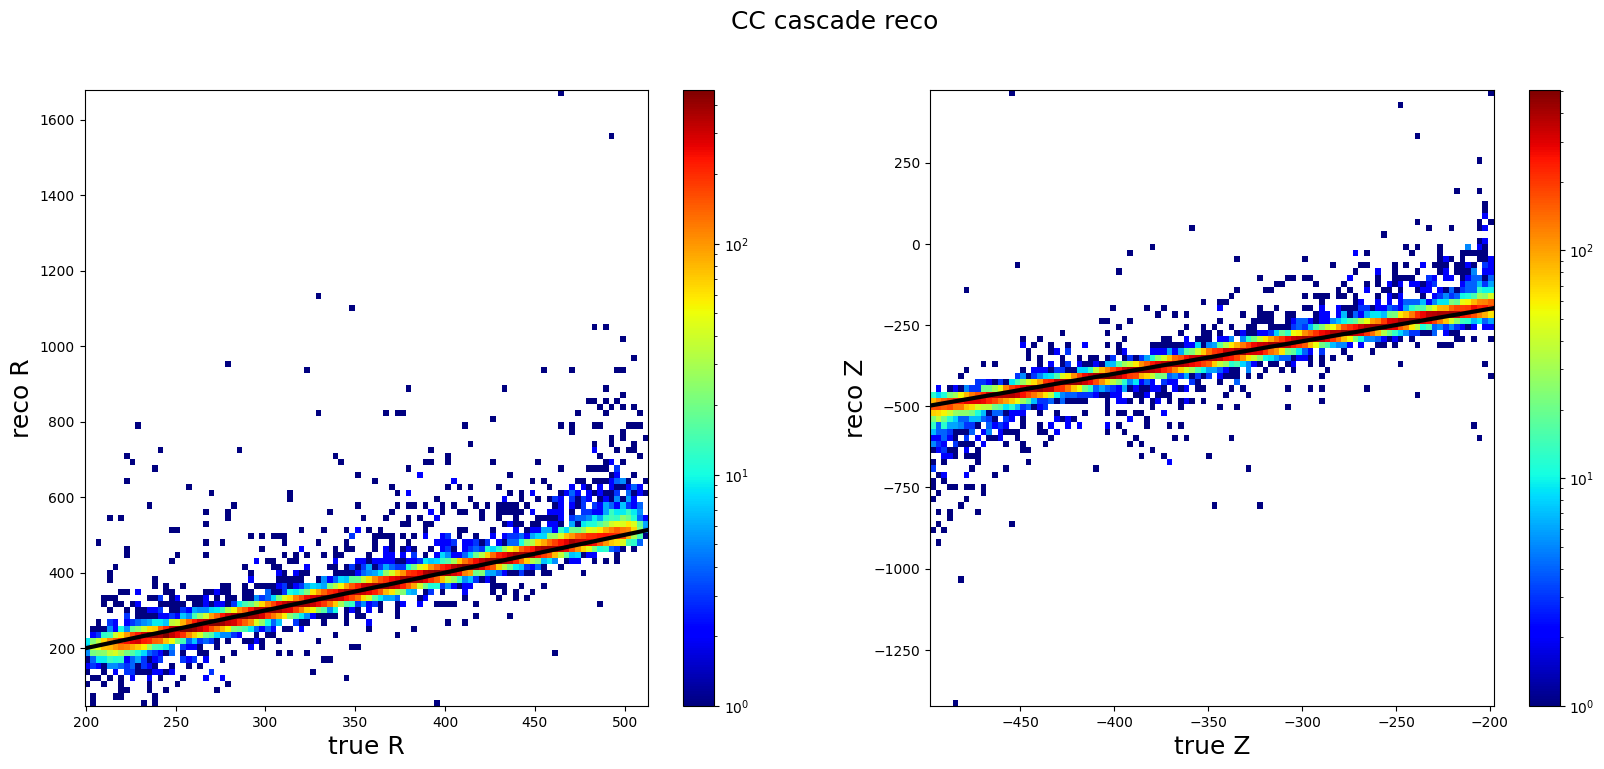

13.97337715990117


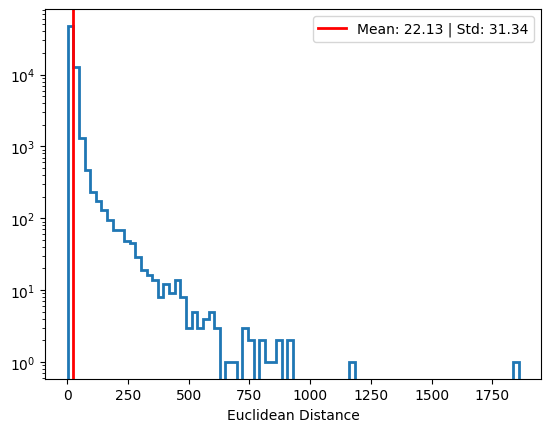

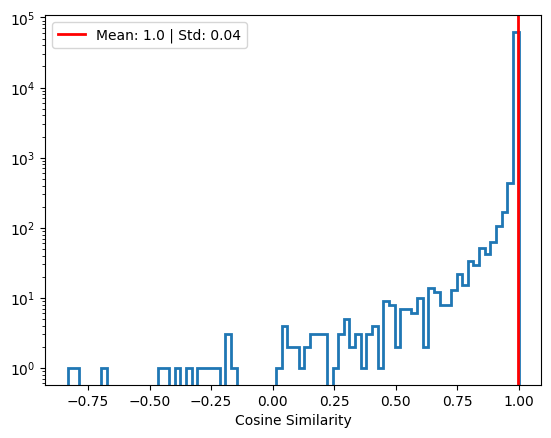

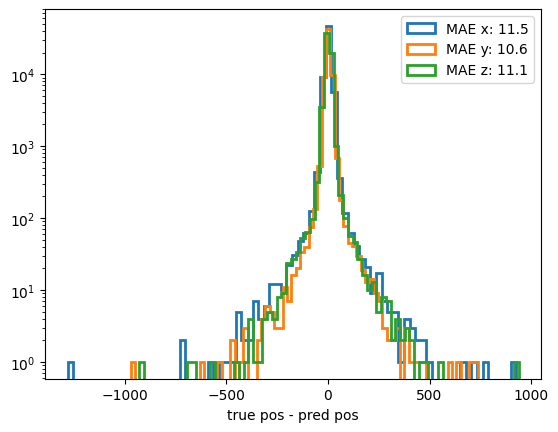

In [10]:
understand_model(position, 'CC cascade reco')